Notebook

In [1]:
!pip install remotezip tqdm opencv-python einops
!pip install -U tensorflow keras
!pip install rarfile

In [2]:
import tqdm
import random
import pathlib
import itertools
import collections

import cv2
import einops
import numpy as np
import remotezip as rz
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import layers

In [3]:
import shutil

folder_path = '/content/hmdb51_extracted'

try:
  shutil.rmtree(folder_path)
  print(f"Folder '{folder_path}' and its contents deleted successfully.")
except FileNotFoundError:
  print(f"Error: Folder '{folder_path}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: Folder '/content/hmdb51_extracted' not found.


In [4]:
#@title

def list_files_per_class(zip_url):
  """
    List the files in each class of the dataset given the zip URL.

    Args:
      zip_url: URL from which the files can be unzipped.

    Return:
      files: List of files in each of the classes.
  """
  files = []
  with rz.RemoteZip(URL) as zip:
    for zip_info in zip.infolist():
      files.append(zip_info.filename)
  return files

def get_class(fname):
  """
    Retrieve the name of the class given a filename.

    Args:
      fname: Name of the file in the UCF101 dataset.

    Return:
      Class that the file belongs to.
  """
  return fname.split('_')[-3]

def get_files_per_class(files):
  """
    Retrieve the files that belong to each class.

    Args:
      files: List of files in the dataset.

    Return:
      Dictionary of class names (key) and files (values).
  """
  files_for_class = collections.defaultdict(list)
  for fname in files:
    class_name = get_class(fname)
    files_for_class[class_name].append(fname)
  return files_for_class

def download_from_zip(zip_url, to_dir, file_names):
  """
    Download the contents of the zip file from the zip URL.

    Args:
      zip_url: Zip URL containing data.
      to_dir: Directory to download data to.
      file_names: Names of files to download.
  """
  with rz.RemoteZip(zip_url) as zip:
    for fn in tqdm.tqdm(file_names):
      class_name = get_class(fn)
      zip.extract(fn, str(to_dir / class_name))
      unzipped_file = to_dir / class_name / fn

      fn = pathlib.Path(fn).parts[-1]
      output_file = to_dir / class_name / fn
      unzipped_file.rename(output_file,)

def split_class_lists(files_for_class, count):
  """
    Returns the list of files belonging to a subset of data as well as the remainder of
    files that need to be downloaded.

    Args:
      files_for_class: Files belonging to a particular class of data.
      count: Number of files to download.

    Return:
      split_files: Files belonging to the subset of data.
      remainder: Dictionary of the remainder of files that need to be downloaded.
  """
  split_files = []
  remainder = {}
  for cls in files_for_class:
    split_files.extend(files_for_class[cls][:count])
    remainder[cls] = files_for_class[cls][count:]
  return split_files, remainder

def download_ufc_101_subset(zip_url, num_classes, splits, download_dir):
  """
    Download a subset of the UFC101 dataset and split them into various parts, such as
    training, validation, and test.

    Args:
      zip_url: Zip URL containing data.
      num_classes: Number of labels.
      splits: Dictionary specifying the training, validation, test, etc. (key) division of data
              (value is number of files per split).
      download_dir: Directory to download data to.

    Return:
      dir: Posix path of the resulting directories containing the splits of data.
  """
  files = list_files_per_class(zip_url)
  for f in files:
    tokens = f.split('/')
    if len(tokens) <= 2:
      files.remove(f) # Remove that item from the list if it does not have a filename

  files_for_class = get_files_per_class(files)

  classes = list(files_for_class.keys())[:num_classes]

  for cls in classes:
    new_files_for_class = files_for_class[cls]
    random.shuffle(new_files_for_class)
    files_for_class[cls] = new_files_for_class

  # Only use the number of classes you want in the dictionary
  files_for_class = {x: files_for_class[x] for x in list(files_for_class)[:num_classes]}

  dirs = {}
  for split_name, split_count in splits.items():
    print(split_name, ":")
    split_dir = download_dir / split_name
    split_files, files_for_class = split_class_lists(files_for_class, split_count)
    download_from_zip(zip_url, split_dir, split_files)
    dirs[split_name] = split_dir

  return dirs

def format_frames(frame, output_size):
  """
    Pad and resize an image from a video.

    Args:
      frame: Image that needs to resized and padded.
      output_size: Pixel size of the output frame image.

    Return:
      Formatted frame with padding of specified output size.
  """
  frame = tf.image.convert_image_dtype(frame, tf.float32)
  frame = tf.image.resize_with_pad(frame, *output_size)
  return frame

def frames_from_video_file(video_path, n_frames, output_size = (224,224), frame_step = 15):
  """
    Creates frames from each video file present for each category.

    Args:
      video_path: File path to the video.
      n_frames: Number of frames to be created per video file.
      output_size: Pixel size of the output frame image.

    Return:
      An NumPy array of frames in the shape of (n_frames, height, width, channels).
  """
  # Read each video frame by frame
  result = []
  src = cv2.VideoCapture(str(video_path))

  video_length = src.get(cv2.CAP_PROP_FRAME_COUNT)

  need_length = 1 + (n_frames - 1) * frame_step

  if need_length > video_length:
    start = 0
  else:
    max_start = video_length - need_length
    start = random.randint(0, max_start + 1)

  src.set(cv2.CAP_PROP_POS_FRAMES, start)
  # ret is a boolean indicating whether read was successful, frame is the image itself
  ret, frame = src.read()
  result.append(format_frames(frame, output_size))

  for _ in range(n_frames - 1):
    for _ in range(frame_step):
      ret, frame = src.read()
    if ret:
      frame = format_frames(frame, output_size)
      result.append(frame)
    else:
      result.append(np.zeros_like(result[0]))
  src.release()
  result = np.array(result)[..., [2, 1, 0]]

  return result

class FrameGenerator:
  def __init__(self, path, n_frames, training = False):
    """ Returns a set of frames with their associated label.

      Args:
        path: Video file paths.
        n_frames: Number of frames.
        training: Boolean to determine if training dataset is being created.
    """
    self.path = path
    self.n_frames = n_frames
    self.training = training
    self.class_names = sorted(set(p.name for p in self.path.iterdir() if p.is_dir()))
    self.class_ids_for_name = dict((name, idx) for idx, name in enumerate(self.class_names))

  def get_files_and_class_names(self):
    video_paths = list(self.path.glob('*/*.avi'))
    classes = [p.parent.name for p in video_paths]
    return video_paths, classes

  def __call__(self):
    video_paths, classes = self.get_files_and_class_names()

    pairs = list(zip(video_paths, classes))

    if self.training:
      random.shuffle(pairs)

    for path, name in pairs:
      video_frames = frames_from_video_file(path, self.n_frames)
      label = self.class_ids_for_name[name] # Encode labels
      yield video_frames, label

In [5]:
# URL = 'https://storage.googleapis.com/thumos14_files/UCF101_videos.zip'
# download_dir = pathlib.Path('./UCF101_subset/')
# subset_paths = download_ufc_101_subset(URL,
#                         num_classes = 10,
#                         splits = {"train": 30, "val": 10, "test": 10},
#                         download_dir = download_dir)

### Downloading & Prepare HMDB51 Dataset

In [6]:
import os
import gdown
import glob
import random
import cv2
import shutil
from tqdm import tqdm

# ===========================
#  CONFIGURATIONS
# ===========================
BASE_DIR = "/content"
DATASET_DIR = os.path.join(BASE_DIR, "hmdb51")
EXTRACTED_DIR = os.path.join(BASE_DIR, "hmdb51_org")
OUTPUT_DIR = os.path.join(BASE_DIR, "HMDB51_prepared")
DATASET_URL = "https://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar"  # Official HMDB51 link
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15  # Dataset split ratios

# Create necessary directories
os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/val", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/test", exist_ok=True)

# ===========================
#  DOWNLOAD DATASET
# ===========================
def download_hmdb51():
    zip_path = os.path.join(DATASET_DIR, "hmdb51_org.rar")
    if not os.path.exists(zip_path):
        print("Downloading HMDB51 dataset...")
        gdown.download(DATASET_URL, zip_path, quiet=False)
    else:
        print("Dataset already downloaded.")
    return zip_path

# ===========================
#  EXTRACT DATASET
# ===========================
def extract_hmdb51(zip_path):
    print("Extracting dataset...")
    os.system(f"unrar x {zip_path} {BASE_DIR}/HMDB51_extract")  # Requires 'unrar' installed
    print("Extraction complete.")

# ===========================
#  EXECUTE PIPELINE
# ===========================
zip_path = download_hmdb51()
# extract_hmdb51(zip_path)

print(f"✅ HMDB51 dataset prepared at: {OUTPUT_DIR}")


Downloading...
From: https://serre-lab.clps.brown.edu/wp-content/uploads/2013/10/hmdb51_org.rar
To: /content/hmdb51/hmdb51_org.rar
100%|██████████| 2.12G/2.12G [00:29<00:00, 71.6MB/s]

✅ HMDB51 dataset prepared at: /content/HMDB51_prepared


In [7]:
import os
import rarfile
from glob import glob
import random
import shutil

# Path to the parent RAR file
parent_rar_path = zip_path

# Path to the directory where you want to extract all the child RAR files
base_extract_path = os.path.join(BASE_DIR, "hmdb51_extracted")

# Ratios for splitting the data
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.15, 0.15
OUTPUT_DIR = os.path.join(BASE_DIR, "HMDB51_prepared")

# Create the base extraction directory if it doesn't exist
os.makedirs(base_extract_path, exist_ok=True)

# Extract the parent RAR file
with rarfile.RarFile(parent_rar_path, 'r') as rf:
    rf.extractall(base_extract_path)

# Find all child RAR files
child_rar_files = glob(os.path.join(base_extract_path, '**', '*.rar'), recursive=True)

# Select only 10 classes
child_rar_files = child_rar_files[:10]

# Create output directories
os.makedirs(f"{OUTPUT_DIR}/train", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/val", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/test", exist_ok=True)

In [8]:
# Function to split data into train, val, and test
def split_data(files, train_ratio, val_ratio, test_ratio):
    random.shuffle(files)
    train_split = int(len(files) * train_ratio)
    val_split = int(len(files) * (train_ratio + val_ratio))
    train_files = files[:train_split]
    val_files = files[train_split:val_split]
    test_files = files[val_split:]
    return train_files, val_files, test_files

In [9]:
# Extract each child RAR file into its own folder and split data
for child_rar_file in child_rar_files:
    # Create a unique directory for each child RAR file
    child_rar_name = os.path.splitext(os.path.basename(child_rar_file))[0]
    child_extract_path = os.path.join(base_extract_path)
    os.makedirs(child_extract_path, exist_ok=True)

    # Extract the child RAR file
    with rarfile.RarFile(child_rar_file, 'r') as rf:
        rf.extractall(child_extract_path)

    print(f"Extracted: {child_rar_file} to {child_extract_path}")

    # Get all the video files in the extracted directory
    video_files = glob(os.path.join(child_extract_path, child_rar_name, '*.avi'))

    # Split the video files into train, val, and test sets
    train_files, val_files, test_files = split_data(video_files, TRAIN_RATIO, VAL_RATIO, TEST_RATIO)

    # Get the action name (folder name)
    action_name = child_rar_name

    # Create action subdirectories in train, val, and test
    os.makedirs(f"{OUTPUT_DIR}/train/{action_name}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/val/{action_name}", exist_ok=True)
    os.makedirs(f"{OUTPUT_DIR}/test/{action_name}", exist_ok=True)

    # Move files to respective directories
    for file in train_files:
        destination = f"{OUTPUT_DIR}/train/{action_name}/{os.path.basename(file)}" # Create the full destination path for check
        if not os.path.exists(destination): # Check if destination exists
          shutil.move(file, f"{OUTPUT_DIR}/train/{action_name}") # Only move if it does not
        else:
          print(f"Skipping move: {file} already exists at {destination}")
    for file in val_files:
        destination = f"{OUTPUT_DIR}/val/{action_name}/{os.path.basename(file)}"
        if not os.path.exists(destination):
          shutil.move(file, f"{OUTPUT_DIR}/val/{action_name}")
        else:
           print(f"Skipping move: {file} already exists at {destination}")
    for file in test_files:
        destination = f"{OUTPUT_DIR}/test/{action_name}/{os.path.basename(file)}"
        if not os.path.exists(destination):
          shutil.move(file, f"{OUTPUT_DIR}/test/{action_name}")
        else:
          print(f"Skipping move: {file} already exists at {destination}")


print("Extraction and splitting of all child RAR files complete.")

Extracted: /content/hmdb51_extracted/dribble.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/sit.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/talk.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/shoot_ball.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/kick_ball.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/fencing.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/situp.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/hug.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/pushup.rar to /content/hmdb51_extracted
Extracted: /content/hmdb51_extracted/climb.rar to /content/hmdb51_extracted
Extraction and splitting of all child RAR files complete.


In [10]:
import pathlib

# Define the base directory where you want the subfolders
base_dir = pathlib.Path('HMDB51_prepared')

# Create the dictionary
hmdb51_subset_paths = {
    'train': base_dir / 'train',
    'val': base_dir / 'val',
    'test': base_dir / 'test'
}

print(hmdb51_subset_paths)

{'train': PosixPath('HMDB51_prepared/train'), 'val': PosixPath('HMDB51_prepared/val'), 'test': PosixPath('HMDB51_prepared/test')}


In [11]:
subset_paths = hmdb51_subset_paths

In [12]:
# import tensorflow as tf

# train_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['train'], n_frames, training=True),
#                                         output_signature = output_signature)

# if len(list(train_ds.take(1))) == 0:
#     print("Dataset is empty")
# else:
#     print("Dataset is not empty")

In [13]:
n_frames = 10
batch_size = 8

output_signature = (tf.TensorSpec(shape = (None, None, None, 3), dtype = tf.float32),
                    tf.TensorSpec(shape = (), dtype = tf.int16))

train_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['train'], n_frames, training=True),
                                          output_signature = output_signature)


# Batch the data
train_ds = train_ds.batch(batch_size)

val_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['val'], n_frames),
                                        output_signature = output_signature)
val_ds = val_ds.batch(batch_size)

test_ds = tf.data.Dataset.from_generator(FrameGenerator(subset_paths['test'], n_frames),
                                         output_signature = output_signature)

test_ds = test_ds.batch(batch_size)

In [14]:
# Define the dimensions of one frame in the set of frames created
HEIGHT = 224
WIDTH = 224

In [15]:
class Conv2Plus1D(keras.layers.Layer):
  def __init__(self, filters, kernel_size, padding):
    """
      A sequence of convolutional layers that first apply the convolution operation over the
      spatial dimensions, and then the temporal dimension.
    """
    super().__init__()
    self.seq = keras.Sequential([
        # Spatial decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(1, kernel_size[1], kernel_size[2]),
                      padding=padding),
        # Temporal decomposition
        layers.Conv3D(filters=filters,
                      kernel_size=(kernel_size[0], 1, 1),
                      padding=padding)
        ])

  def call(self, x):
    return self.seq(x)

In [16]:
class ResidualMain(keras.layers.Layer):
  """
    Residual block of the model with convolution, layer normalization, and the
    activation function, ReLU.
  """
  def __init__(self, filters, kernel_size):
    super().__init__()
    self.seq = keras.Sequential([
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization(),
        layers.ReLU(),
        Conv2Plus1D(filters=filters,
                    kernel_size=kernel_size,
                    padding='same'),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

In [17]:
class Project(keras.layers.Layer):
  """
    Project certain dimensions of the tensor as the data is passed through different
    sized filters and downsampled.
  """
  def __init__(self, units):
    super().__init__()
    self.seq = keras.Sequential([
        layers.Dense(units),
        layers.LayerNormalization()
    ])

  def call(self, x):
    return self.seq(x)

In [18]:
def add_residual_block(input, filters, kernel_size):
  """
    Add residual blocks to the model. If the last dimensions of the input data
    and filter size does not match, project it such that last dimension matches.
  """
  out = ResidualMain(filters,
                     kernel_size)(input)

  res = input
  # Using the Keras functional APIs, project the last dimension of the tensor to
  # match the new filter size
  if out.shape[-1] != input.shape[-1]:
    res = Project(out.shape[-1])(res)

  return layers.add([res, out])

In [19]:
class ResizeVideo(keras.layers.Layer):
  def __init__(self, height, width):
    super().__init__()
    self.height = height
    self.width = width
    self.resizing_layer = layers.Resizing(self.height, self.width)

  def call(self, video):
    """
      Use the einops library to resize the tensor.

      Args:
        video: Tensor representation of the video, in the form of a set of frames.

      Return:
        A downsampled size of the video according to the new height and width it should be resized to.
    """
    # b stands for batch size, t stands for time, h stands for height,
    # w stands for width, and c stands for the number of channels.
    old_shape = einops.parse_shape(video, 'b t h w c')
    images = einops.rearrange(video, 'b t h w c -> (b t) h w c')
    images = self.resizing_layer(images)
    videos = einops.rearrange(
        images, '(b t) h w c -> b t h w c',
        t = old_shape['t'])
    return videos

In [20]:
input_shape = (None, 10, HEIGHT, WIDTH, 3)
input = layers.Input(shape=(input_shape[1:]))
x = input

x = Conv2Plus1D(filters=16, kernel_size=(3, 7, 7), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = ResizeVideo(HEIGHT // 2, WIDTH // 2)(x)

# Block 1
x = add_residual_block(x, 16, (3, 3, 3))
x = ResizeVideo(HEIGHT // 4, WIDTH // 4)(x)

# Block 2
x = add_residual_block(x, 32, (3, 3, 3))
x = ResizeVideo(HEIGHT // 8, WIDTH // 8)(x)

# Block 3
x = add_residual_block(x, 64, (3, 3, 3))
x = ResizeVideo(HEIGHT // 16, WIDTH // 16)(x)

# Block 4
x = add_residual_block(x, 128, (3, 3, 3))

x = layers.GlobalAveragePooling3D()(x)
x = layers.Flatten()(x)
x = layers.Dense(10)(x)

model = keras.Model(input, x)

In [21]:
frames, label = next(iter(train_ds))
model.build(frames)

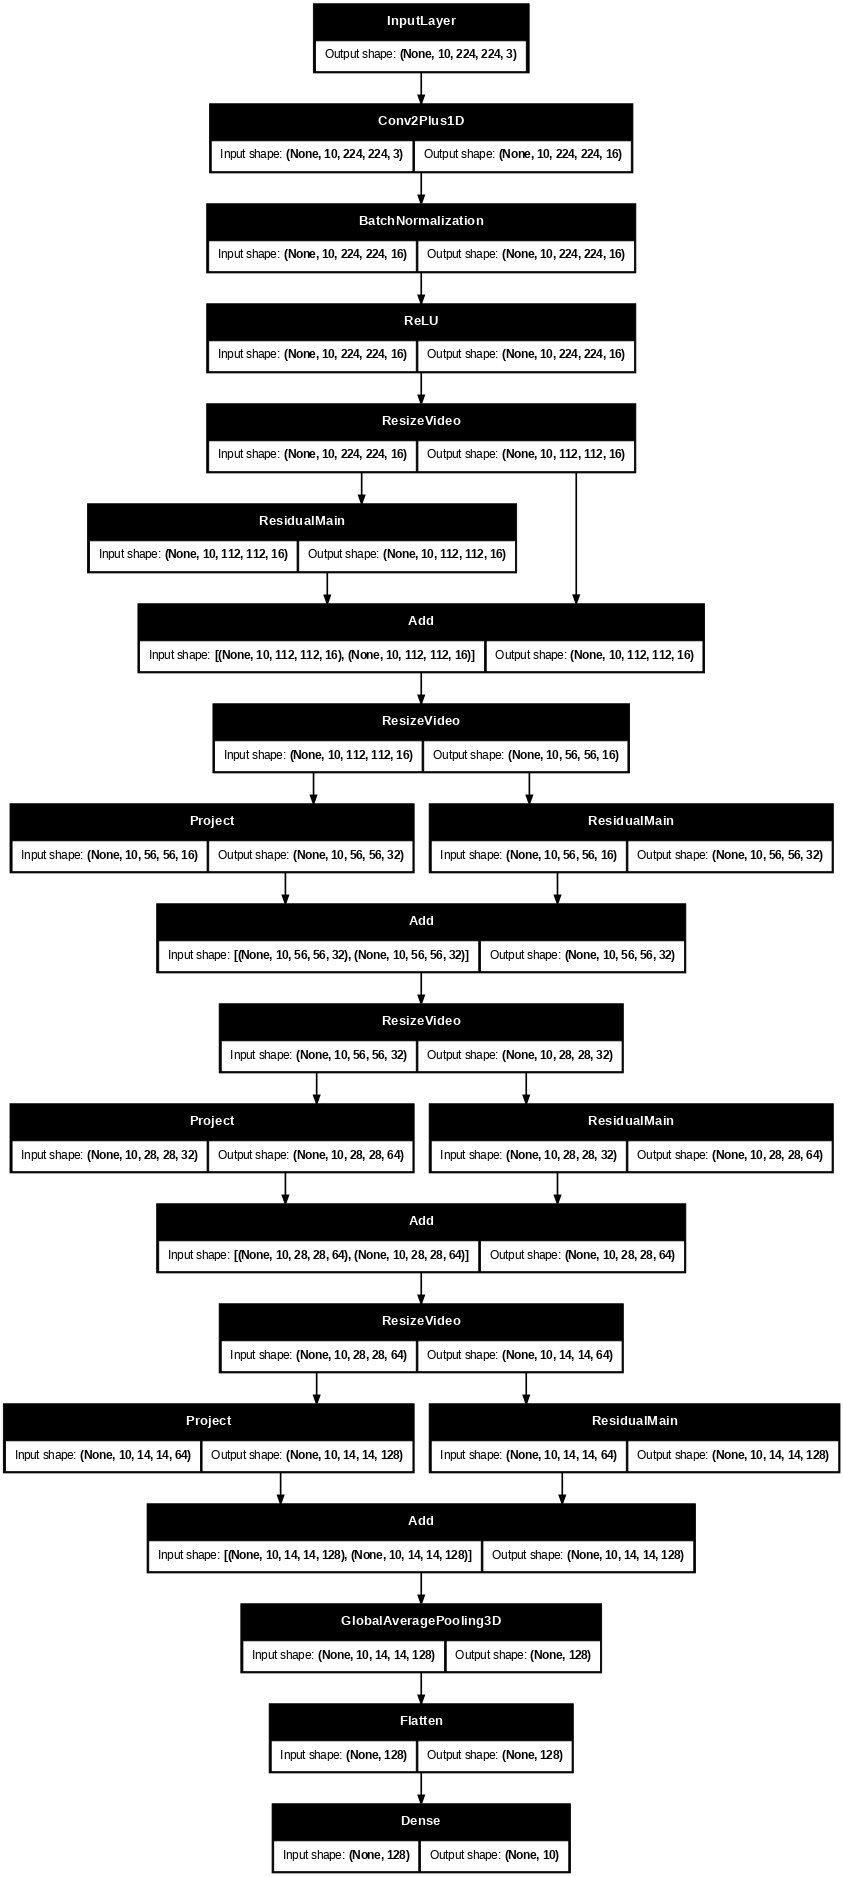

In [22]:
# Visualize the model
keras.utils.plot_model(model, expand_nested=True, dpi=60, show_shapes=True)

In [23]:
model.compile(loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = keras.optimizers.Adam(learning_rate = 0.0001),
              metrics = ['accuracy'])

In [24]:
history = model.fit(x = train_ds,
                    epochs = 2,
                    validation_data = val_ds)

Epoch 1/2
    106/Unknown 161s 1s/step - accuracy: 0.2062 - loss: 2.2862

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


106/106 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.2063 - loss: 2.2850 - val_accuracy: 0.2033 - val_loss: 2.0400
Epoch 2/2
106/106 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.2585 - loss: 1.9592 - val_accuracy: 0.2308 - val_loss: 2.0624


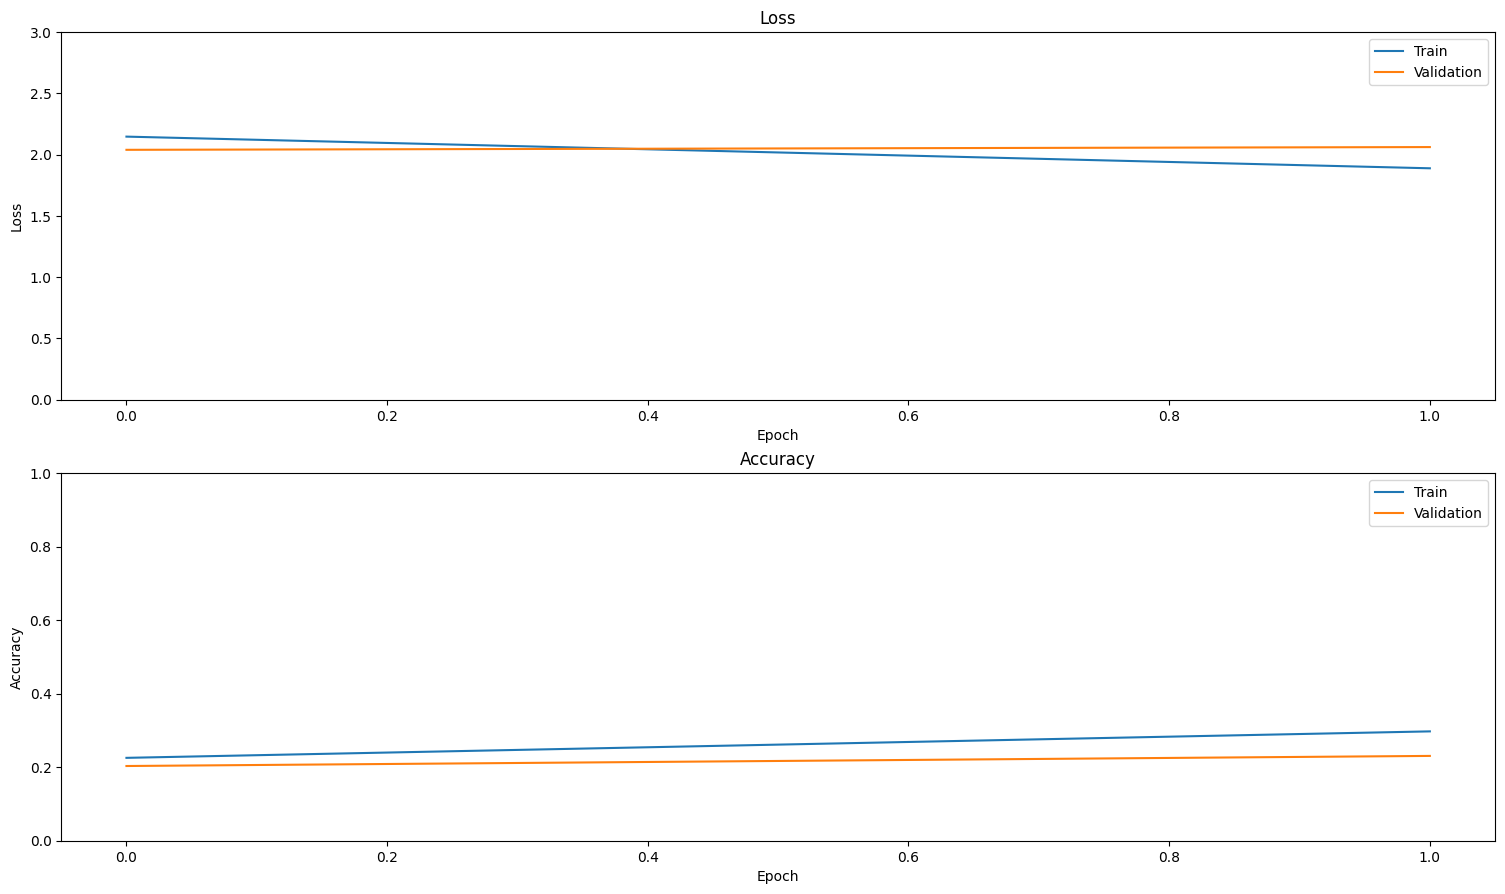

In [25]:
def plot_history(history):
  """
    Plotting training and validation learning curves.

    Args:
      history: model history with all the metric measures
  """
  fig, (ax1, ax2) = plt.subplots(2)

  fig.set_size_inches(18.5, 10.5)

  # Plot loss
  ax1.set_title('Loss')
  ax1.plot(history.history['loss'], label = 'train')
  ax1.plot(history.history['val_loss'], label = 'test')
  ax1.set_ylabel('Loss')

  # Determine upper bound of y-axis
  max_loss = max(history.history['loss'] + history.history['val_loss'])

  ax1.set_ylim([0, np.ceil(max_loss)])
  ax1.set_xlabel('Epoch')
  ax1.legend(['Train', 'Validation'])

  # Plot accuracy
  ax2.set_title('Accuracy')
  ax2.plot(history.history['accuracy'],  label = 'train')
  ax2.plot(history.history['val_accuracy'], label = 'test')
  ax2.set_ylabel('Accuracy')
  ax2.set_ylim([0, 1])
  ax2.set_xlabel('Epoch')
  ax2.legend(['Train', 'Validation'])

  plt.show()

plot_history(history)

In [26]:
model.evaluate(test_ds, return_dict=True)

24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.2363 - loss: 2.0315


{'accuracy': 0.22994652390480042, 'loss': 2.112647533416748}

In [27]:
def get_actual_predicted_labels(dataset):
  """
    Create a list of actual ground truth values and the predictions from the model.

    Args:
      dataset: An iterable data structure, such as a TensorFlow Dataset, with features and labels.

    Return:
      Ground truth and predicted values for a particular dataset.
  """
  actual = [labels for _, labels in dataset.unbatch()]
  predicted = model.predict(dataset)

  actual = tf.stack(actual, axis=0)
  predicted = tf.concat(predicted, axis=0)
  predicted = tf.argmax(predicted, axis=1)

  return actual, predicted

In [28]:
def plot_confusion_matrix(actual, predicted, labels, ds_type):
  cm = tf.math.confusion_matrix(actual, predicted)
  ax = sns.heatmap(cm, annot=True, fmt='g')
  sns.set(rc={'figure.figsize':(12, 12)})
  sns.set(font_scale=1.4)
  ax.set_title('Confusion matrix of action recognition for ' + ds_type)
  ax.set_xlabel('Predicted Action')
  ax.set_ylabel('Actual Action')
  plt.xticks(rotation=90)
  plt.yticks(rotation=0)
  ax.xaxis.set_ticklabels(labels)
  ax.yaxis.set_ticklabels(labels)

In [29]:
fg = FrameGenerator(subset_paths['train'], n_frames, training=True)
labels = list(fg.class_ids_for_name.keys())

106/106 ━━━━━━━━━━━━━━━━━━━━ 94s 855ms/step


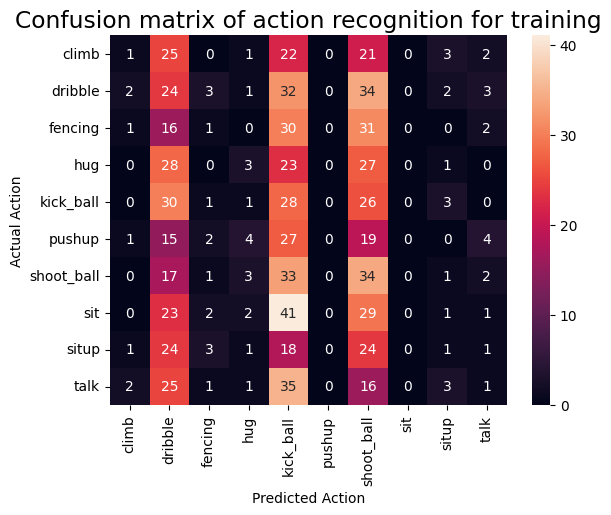

In [30]:
actual, predicted = get_actual_predicted_labels(train_ds)
plot_confusion_matrix(actual, predicted, labels, 'training')

24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 915ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


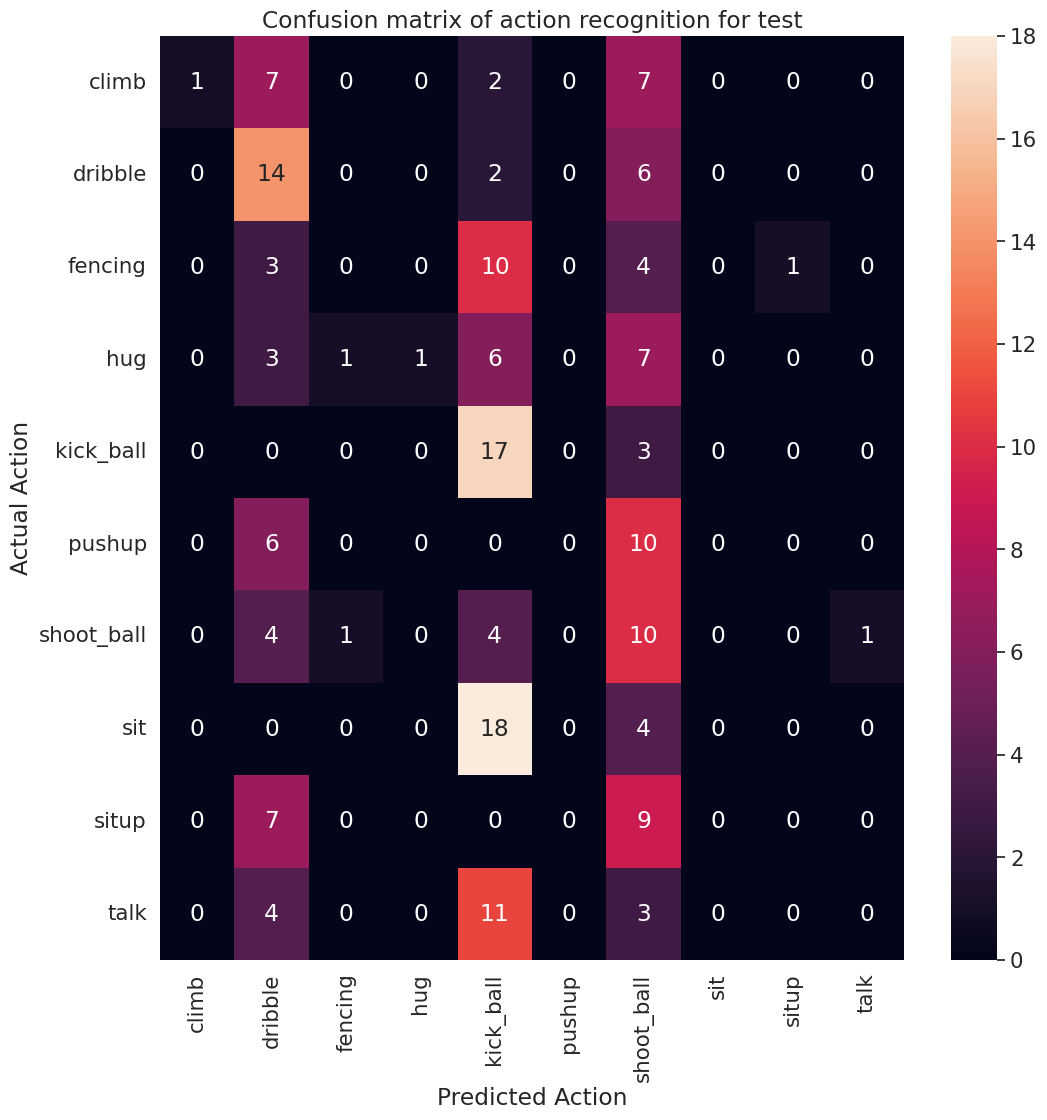

In [31]:
actual, predicted = get_actual_predicted_labels(test_ds)
plot_confusion_matrix(actual, predicted, labels, 'test')

In [32]:
def calculate_classification_metrics(y_actual, y_pred, labels):
  """
    Calculate the precision and recall of a classification model using the ground truth and
    predicted values.

    Args:
      y_actual: Ground truth labels.
      y_pred: Predicted labels.
      labels: List of classification labels.

    Return:
      Precision and recall measures.
  """
  cm = tf.math.confusion_matrix(y_actual, y_pred)
  tp = np.diag(cm) # Diagonal represents true positives
  precision = dict()
  recall = dict()
  for i in range(len(labels)):
    col = cm[:, i]
    fp = np.sum(col) - tp[i] # Sum of column minus true positive is false negative

    row = cm[i, :]
    fn = np.sum(row) - tp[i] # Sum of row minus true positive, is false negative

    precision[labels[i]] = tp[i] / (tp[i] + fp) # Precision

    recall[labels[i]] = tp[i] / (tp[i] + fn) # Recall

  return precision, recall

In [33]:
precision, recall = calculate_classification_metrics(actual, predicted, labels) # Test dataset

<ipython-input-32-255a546016d8>:25: RuntimeWarning: invalid value encountered in scalar divide
  precision[labels[i]] = tp[i] / (tp[i] + fp) # Precision


In [34]:
precision

{'climb': 1.0,
 'dribble': 0.2916666666666667,
 'fencing': 0.0,
 'hug': 1.0,
 'kick_ball': 0.24285714285714285,
 'pushup': nan,
 'shoot_ball': 0.15873015873015872,
 'sit': nan,
 'situp': 0.0,
 'talk': 0.0}

In [35]:
recall

{'climb': 0.058823529411764705,
 'dribble': 0.6363636363636364,
 'fencing': 0.0,
 'hug': 0.05555555555555555,
 'kick_ball': 0.85,
 'pushup': 0.0,
 'shoot_ball': 0.5,
 'sit': 0.0,
 'situp': 0.0,
 'talk': 0.0}

Predicting on video: /content/HMDB51_prepared/test/climb/Pole_Climbing_Challenging_gravity_climb_f_cm_np1_ba_med_2.avi
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Prediction:  climb


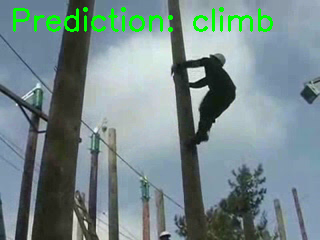

In [38]:
import cv2
import tensorflow as tf
import numpy as np
from google.colab.patches import cv2_imshow


def predict_on_video(video_path):
    """Predicts the action in a given video and displays its first frame."""
    try:
        # Open the video file
        cap = cv2.VideoCapture(video_path)

        # Read the first frame
        ret, frame = cap.read()

        if not ret:
            print("Error: Could not read the video file.")
            return

        # Resize the frame
        resized_frame = cv2.resize(frame, (WIDTH, HEIGHT))

        # Convert frame to tensor
        input_frame = tf.expand_dims(resized_frame, axis=0)
        input_frames = tf.expand_dims(input_frame, axis=0) # add batch and time dimension

        # Create fake input array with batch size 1 and 10 frames (adjust as needed)
        input_frames = tf.repeat(input_frames, repeats=n_frames, axis=1)

        # Make a prediction
        predictions = model.predict(input_frames)
        predicted_class_index = tf.argmax(predictions[0]).numpy()
        predicted_class = labels[predicted_class_index]

        print("Prediction: ", predicted_class)

        # Display the first frame with the prediction
        cv2.putText(frame, f"Prediction: {predicted_class}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2_imshow(frame)


    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage:
path_string = "/content/HMDB51_prepared/test/climb/Pole_Climbing_Challenging_gravity_climb_f_cm_np1_ba_med_2.avi"
test_video_path = pathlib.Path(path_string)
# test_video_path = list(subset_paths['test'].glob('**/*.avi'))[0] # Get the path of a video in the test set
print(f"Predicting on video: {test_video_path}")
predict_on_video(str(test_video_path)) # Convert pathlib.Path to string